In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Canonical variable candidate check

Select any of the six canonical variables, inspect candidate coverage, apply its plausible-value rule, and draw time-series and ECDF figures.

In [26]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlalchemy as sa
from IPython.display import display

HERE = Path.cwd()
if not (HERE / 'network_var_mapping.py').exists():
    HERE = Path('/workspaces/crmprtd/Quanlity_Control/pipeline/v2_July/variable_mapping_using_all_stations')
sys.path.insert(0, str(HERE))
from network_var_mapping import *

DB_URL = os.getenv(
    'CRMP_DB_URL',
    'postgresql://tongli1997@proddb01.pcic.uvic.ca,proddb02.pcic.uvic.ca/crmp'
    '?keepalives=1&keepalives_idle=300&keepalives_interval=300'
    '&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass',
)
engine = sa.create_engine(DB_URL, pool_pre_ping=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Parameters

Change `CANONICAL_VARIABLE` to any value shown in `CANONICAL_VARIABLES`. Use `STATION_OFFSET=0` for the first group, `5` for the next group, and so on.

In [95]:
# Change only these two values when reviewing the next variable.
CANONICAL_VARIABLE = 'snow_depth'
FINAL_SOURCE_IDS = []  # Fill this after reviewing the plots.
PLOT_VARIABLE_IDS = None  # For example: [434, 721]; None plots all candidates.
NETWORK_ID = 2
STATION_LIMIT = 5
STATION_OFFSET = 50
FIGURE_DIR = HERE / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print('Current variable:', CANONICAL_VARIABLE, sep='\n* ')

print('-----' * 5)
print('Available variables:')
print(*CANONICAL_VARIABLES, sep='\n')

if CANONICAL_VARIABLE not in CANONICAL_VARIABLES:
    raise ValueError(f'Choose one of: {CANONICAL_VARIABLES}')

Current variable:
* snow_depth
-------------------------
Available variables:
air_temperature
daily_min_temperature
daily_max_temperature
precipitation_amount
snowfall_amount
snow_depth


## 2. Select stations and load data

In [96]:
# Load the persistent registry directly from CSV.
REGISTRY_PATH = HERE / 'candidate_mappings.csv'
all_candidate_mappings = pd.read_csv(REGISTRY_PATH)
candidate_mappings = all_candidate_mappings[
    all_candidate_mappings['network_id'] == NETWORK_ID
].copy()
if candidate_mappings.empty:
    raise ValueError(
        f'No saved mappings for network {NETWORK_ID} in {REGISTRY_PATH}')

candidate_rows = candidate_mappings[
    candidate_mappings['canonical_variable'] == CANONICAL_VARIABLE
]
if candidate_rows.empty:
    raise ValueError(
        f'No {CANONICAL_VARIABLE} candidates saved for network {NETWORK_ID}'
    )
candidate_ids = candidate_rows['vars_id'].tolist()
display(candidate_rows)

comparison_stations = select_candidate_stations(
    engine, candidate_ids, network_id=NETWORK_ID,
    limit=STATION_LIMIT, offset=STATION_OFFSET
)
if comparison_stations.empty:
    raise ValueError(
        'No stations found. Try a smaller offset or review the candidates.')
comparison_station_ids = comparison_stations['station_id'].tolist()
display(comparison_stations)

candidate_profile = profile_candidate_variables(
    engine, candidate_ids, network_id=NETWORK_ID,
    station_ids=comparison_station_ids
)
candidate_summary = summarize_candidate_profiles(candidate_profile)
display(candidate_summary.round(2))
display(candidate_profile)

,network_id,vars_id,net_var_name,canonical_variable,daily_aggregation,priority,source_family,mapping_status
12,2,450,HEIGHT_OF_SNOW,snow_depth,fixed_hour,1,network2_auto,needs_review
13,2,727,snw_dpth,snow_depth,fixed_hour,2,network2_auto,needs_review


,station_id,station_name
0,2816,Caribou Ridge
1,2817,50 Mile
2,2818,Fred Laing Ridge
3,2819,Mica
4,2821,Galena Pass


/tmp/ipykernel_52791/510237115.py:36: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(candidate_summary.round(2))


,vars_id,net_var_name,station_count,first_observation,last_observation,median_station_span_years,median_active_years
0,450,HEIGHT_OF_SNOW,5,1988-01-22 10:00:00,2023-03-18 09:00:00,19.35,9.0
1,727,snw_dpth,5,2020-01-08 11:00:00,2026-07-27 10:00:00,6.33,5.0


,station_id,station_name,vars_id,net_var_name,active_years,coverage_years,first_observation,last_observation,observed_min,observed_max
0,2816,Caribou Ridge,450,HEIGHT_OF_SNOW,1,0.092971,1990-11-09 12:01:00,1990-12-12 11:00:00,0.000,0.0
1,2816,Caribou Ridge,727,snw_dpth,2,1.552247,2020-01-08 11:00:00,2021-07-27 10:00:00,-6999.000,-6999.0
2,2817,50 Mile,450,HEIGHT_OF_SNOW,21,19.345996,2003-11-13 06:00:00,2023-03-18 09:00:00,-12.060,196.0
3,2817,50 Mile,727,snw_dpth,7,6.325234,2020-01-08 11:00:00,2026-05-05 18:00:00,-55.000,167.0
4,2818,Fred Laing Ridge,450,HEIGHT_OF_SNOW,5,9.842345,1998-02-02 13:00:00,2007-12-06 11:00:00,0.000,0.0
5,2818,Fred Laing Ridge,727,snw_dpth,1,0.675679,2020-01-08 11:00:00,2020-09-10 06:00:00,-6999.000,-6999.0
6,2819,Mica,450,HEIGHT_OF_SNOW,24,23.159366,2000-01-20 10:00:00,2023-03-18 09:00:00,-3.238,198.9
7,2819,Mica,727,snw_dpth,7,6.379192,2020-01-08 12:00:00,2026-05-25 12:00:00,-6999.000,169.0
8,2821,Galena Pass,450,HEIGHT_OF_SNOW,9,20.159138,1988-01-22 10:00:00,2008-03-19 13:00:00,0.000,101.0
9,2821,Galena Pass,727,snw_dpth,5,6.551563,2020-01-08 11:00:00,2026-07-27 10:00:00,-6999.000,351.0


## 3. Apply the canonical plausible-value rule

In [97]:
observations = fetch_candidate_observations(
    engine, candidate_ids, comparison_station_ids
)
clean_data, qc_summary = apply_canonical_rule(
    observations, CANONICAL_VARIABLE
)
display(qc_summary.round(2))

,station_id,net_var_name,row_count,removed_count,removed_pct
0,2816,HEIGHT_OF_SNOW,764,0,0.00
1,2816,snw_dpth,13250,13250,100.00
2,2817,HEIGHT_OF_SNOW,102595,18687,18.21
3,2817,snw_dpth,28440,1345,4.73
4,2818,HEIGHT_OF_SNOW,32576,0,0.00
5,2818,snw_dpth,5472,5472,100.00
6,2819,HEIGHT_OF_SNOW,136745,20545,15.02
7,2819,snw_dpth,29101,2111,7.25
8,2821,HEIGHT_OF_SNOW,34740,0,0.00
9,2821,snw_dpth,24993,12659,50.65


## 4. Time series

In [ ]:
# PLOT_VARIABLE_IDS = [442, 726]  # For example: [434, 721]; None plots all candidates.


Saved: /workspaces/crmprtd/Quanlity_Control/pipeline/v2_July/variable_mapping_using_all_stations/figures/network_2_snow_depth_time_series.png


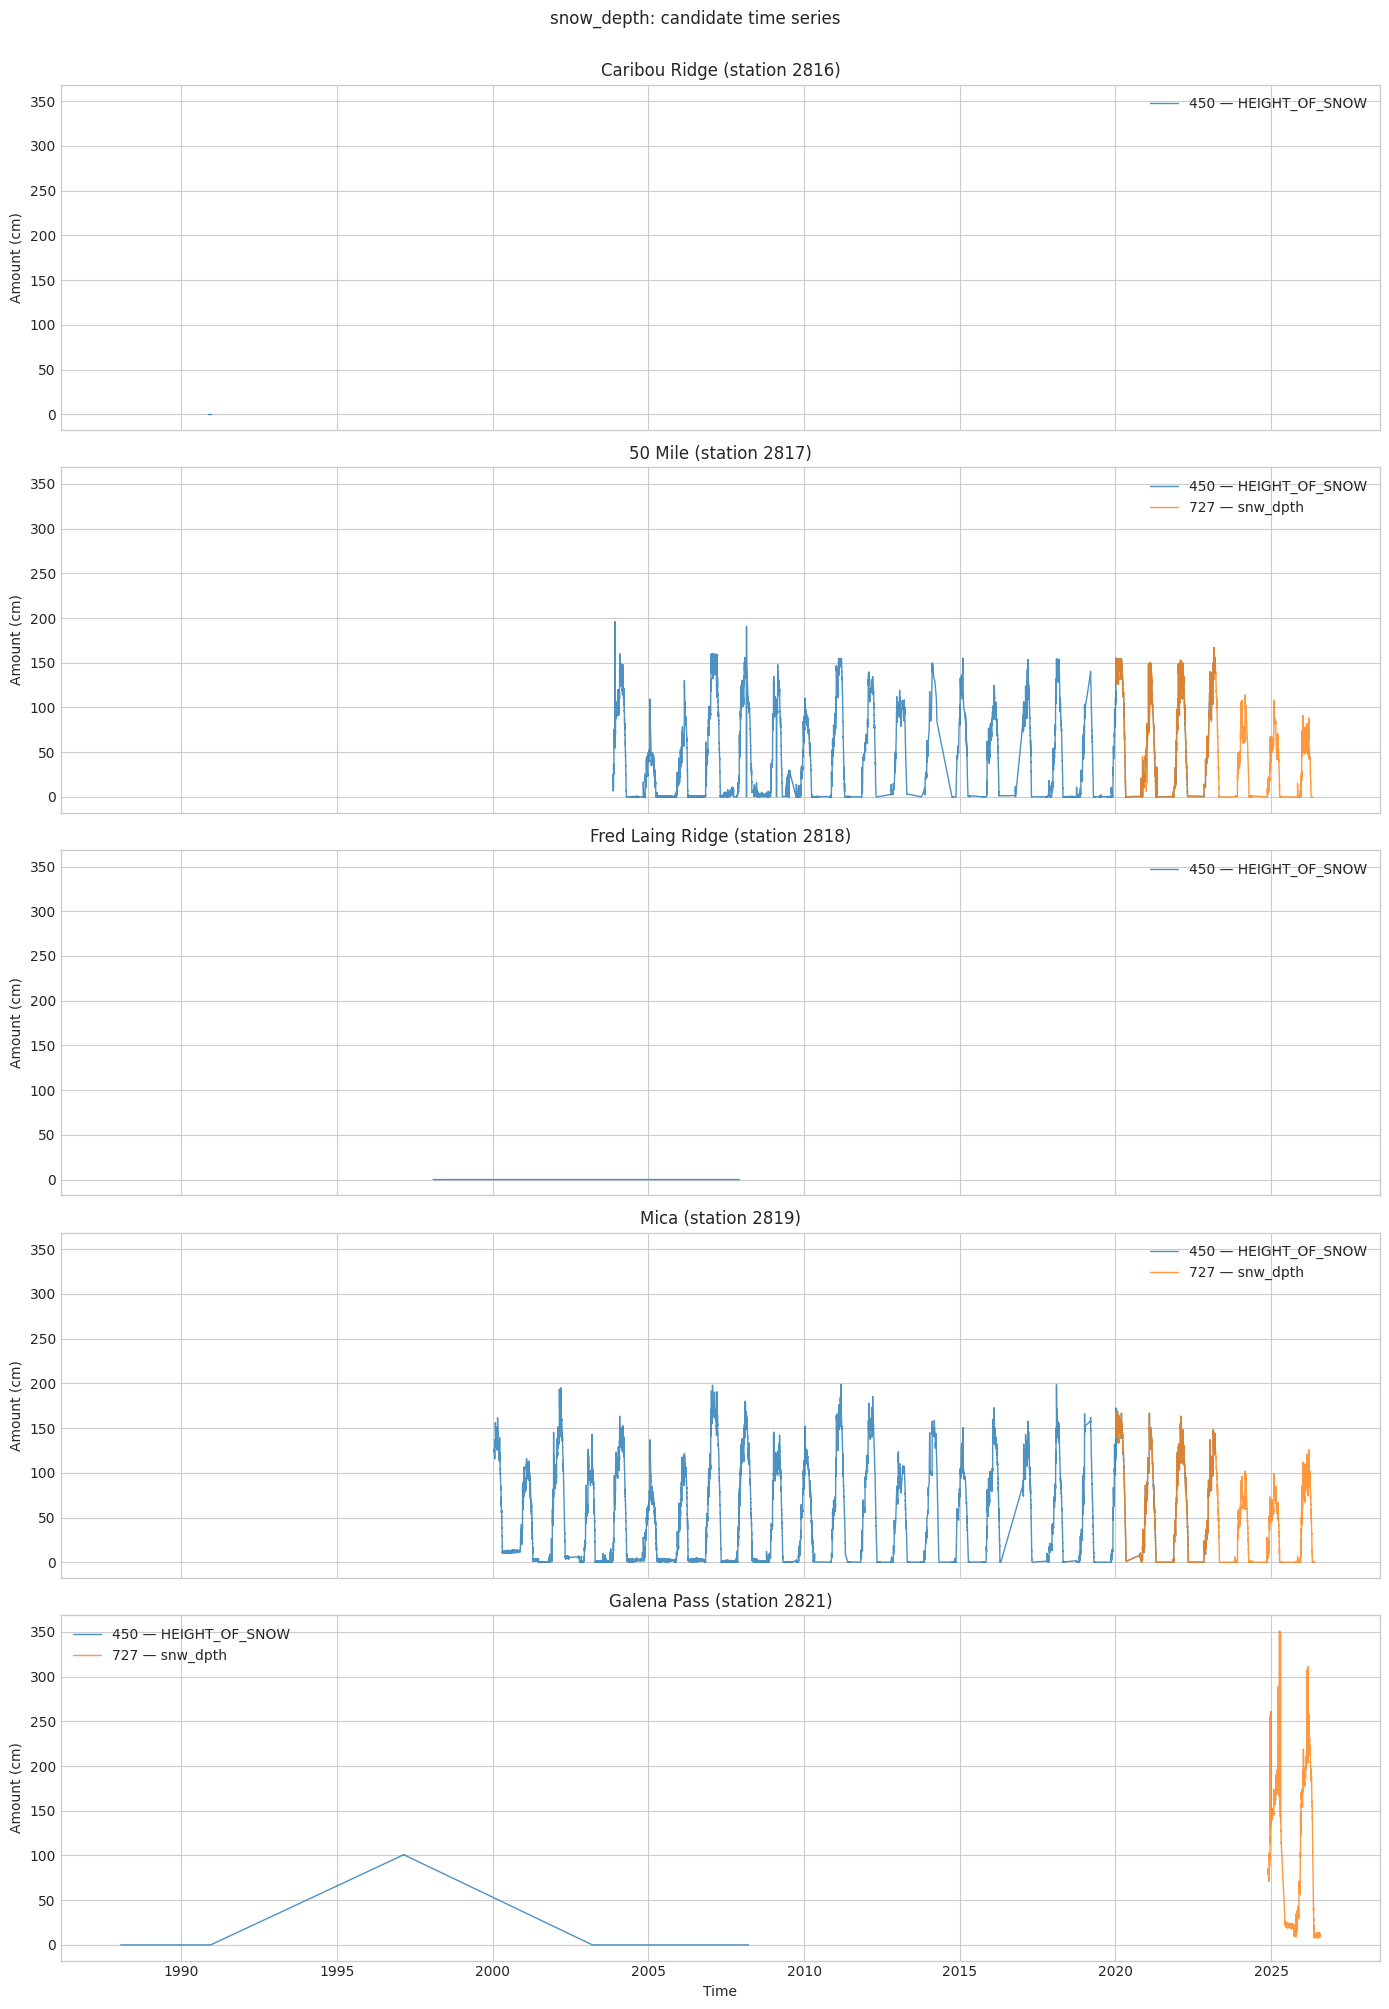

In [98]:
unit_labels = {
    'celsius': 'Temperature (°C)', 'mm': 'Amount (mm)', 'cm': 'Amount (cm)'}
ylabel = unit_labels[CANONICAL_RULES[CANONICAL_VARIABLE].unit]
plot_data = clean_data
if PLOT_VARIABLE_IDS is not None:
    plot_data = clean_data[
        clean_data['vars_id'].isin(PLOT_VARIABLE_IDS)
    ].copy()
    if plot_data.empty:
        raise ValueError(
            'None of PLOT_VARIABLE_IDS has valid data for the selected stations.'
        )

stations = list(plot_data.groupby('station_id'))

fig, axes = plt.subplots(len(stations), 1, figsize=(14, 4 * len(stations)),
                         sharex=True, sharey=True, squeeze=False)
for ax, (station_id, station_data) in zip(axes.ravel(), stations):
    for (vars_id, variable_name), variable_data in station_data.groupby(
        ['vars_id', 'net_var_name']
    ):
        ax.plot(variable_data['obs_time'], variable_data['datum'],
                linewidth=1, alpha=0.8,
                label=f'{vars_id} — {variable_name}')
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_ylabel(ylabel)
    ax.legend()
axes[-1, 0].set_xlabel('Time')
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate time series', y=1.002)
plt.tight_layout()
time_series_path = FIGURE_DIR / (
    f'network_{NETWORK_ID}_{CANONICAL_VARIABLE}_time_series.png'
)
fig.savefig(time_series_path, dpi=150, bbox_inches='tight')
print(f'Saved: {time_series_path}')
plt.show()

## 5. Empirical cumulative distributions

Precipitation and snowfall ECDFs use positive values only and a logarithmic amount axis. Temperature and snow-depth ECDFs retain all plausible values.

Saved: /workspaces/crmprtd/Quanlity_Control/pipeline/v2_July/variable_mapping_using_all_stations/figures/network_2_snow_depth_cdf.png


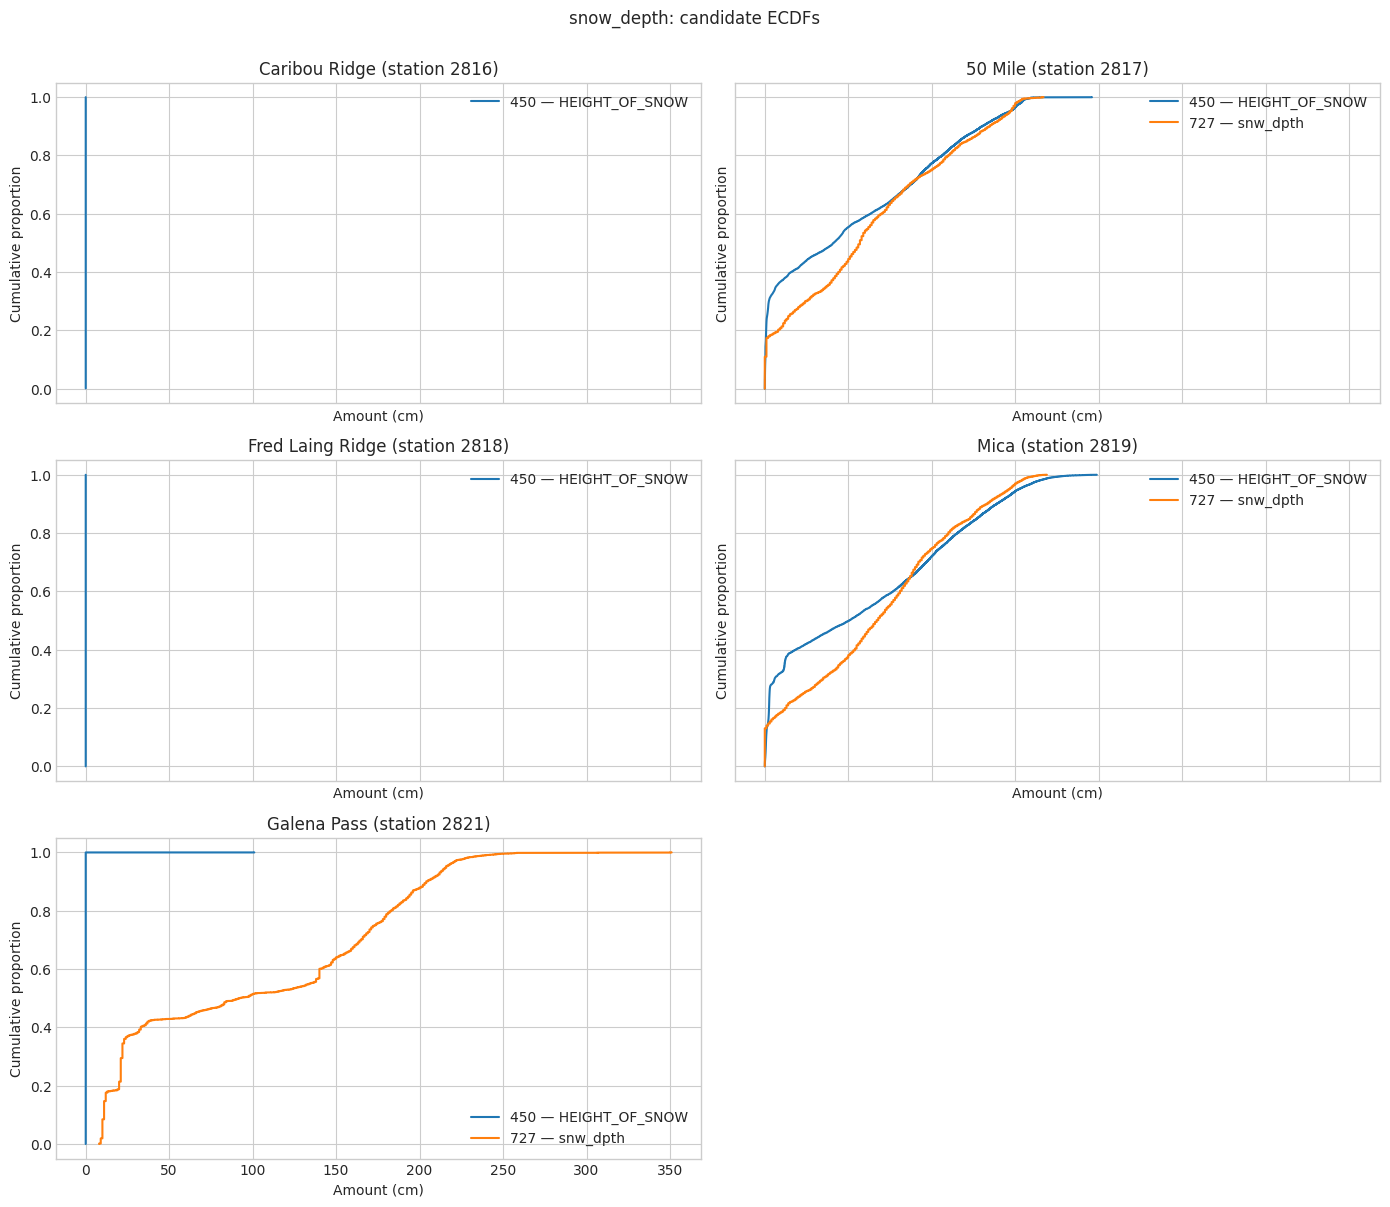

In [99]:
positive_only = CANONICAL_VARIABLE in {
    'precipitation_amount', 'snowfall_amount'}
log_x = positive_only
ncols = 2
nrows = int(np.ceil(len(stations) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                         sharex=True, sharey=True, squeeze=False)
axes = axes.ravel()

for ax, (station_id, station_data) in zip(axes, stations):
    for (vars_id, variable_name), variable_data in station_data.groupby(
        ['vars_id', 'net_var_name']
    ):
        values = variable_data['datum'].dropna()
        if positive_only:
            values = values[values > 0]
        values = np.sort(values.to_numpy())
        if len(values):
            cumulative = np.arange(1, len(values) + 1) / len(values)
            ax.step(values, cumulative, where='post',
                    label=f'{vars_id} — {variable_name}')
    if log_x:
        ax.set_xscale('log')
    ax.set_title(
        f"{station_data['station_name'].iloc[0]} (station {station_id})")
    ax.set_xlabel(
        ylabel + (' — positive values, log scale' if positive_only else ''))
    ax.set_ylabel('Cumulative proportion')
    ax.legend()

for ax in axes[len(stations):]:
    ax.set_visible(False)
fig.suptitle(f'{CANONICAL_VARIABLE}: candidate ECDFs', y=1.002)
plt.tight_layout()
cdf_path = FIGURE_DIR / (
    f'network_{NETWORK_ID}_{CANONICAL_VARIABLE}_cdf.png'
)
fig.savefig(cdf_path, dpi=150, bbox_inches='tight')
print(f'Saved: {cdf_path}')
plt.show()

In [101]:
# Record the reviewed selection and merge policy; do not combine data here.
import json
FINAL_SOURCE_IDS = [450, 727]
FINAL_RULE_PATH = HERE / 'final_variable_rules.csv'

if not FINAL_SOURCE_IDS:
    print(
        f'No rule saved for {CANONICAL_VARIABLE}: review the figures, '
        'fill FINAL_SOURCE_IDS in the setup cell, then rerun this cell.'
    )
else:
    unknown_ids = set(FINAL_SOURCE_IDS) - set(candidate_ids)
    if unknown_ids:
        raise ValueError(
            f'FINAL_SOURCE_IDS are not candidates for '
            f'{CANONICAL_VARIABLE}: {sorted(unknown_ids)}'
        )

    final_rule = pd.DataFrame([{
        'network_id': NETWORK_ID,
        'canonical_variable': CANONICAL_VARIABLE,
        'source_vars_ids': json.dumps(FINAL_SOURCE_IDS),
        'time_match': 'exact_timestamp',
        'overlap_method': 'mean',
        'single_source_method': 'use_available',
    }])

    if FINAL_RULE_PATH.exists():
        saved_rules = pd.read_csv(FINAL_RULE_PATH)
        same_mapping = (
            (saved_rules['network_id'] == NETWORK_ID)
            & (saved_rules['canonical_variable'] == CANONICAL_VARIABLE)
        )
        saved_rules = saved_rules.loc[~same_mapping]
        final_rules = pd.concat(
            [saved_rules, final_rule], ignore_index=True
        )
    else:
        final_rules = final_rule

    final_rules = final_rules.sort_values(
        ['network_id', 'canonical_variable']
    ).reset_index(drop=True)
    final_rules.to_csv(FINAL_RULE_PATH, index=False)
    print(f'Saved rule: {NETWORK_ID} / {CANONICAL_VARIABLE}')
    display(final_rules)

Saved rule: 2 / snow_depth


,network_id,canonical_variable,source_vars_ids,time_match,overlap_method,single_source_method
0,2,air_temperature,"[434, 721]",exact_timestamp,mean,use_available
1,2,daily_max_temperature,"[433, 720]",exact_timestamp,mean,use_available
2,2,daily_min_temperature,"[435, 722]",exact_timestamp,mean,use_available
3,2,precipitation_amount,"[442, 726]",exact_timestamp,mean,use_available
4,2,snow_depth,"[450, 727]",exact_timestamp,mean,use_available
5,2,snowfall_amount,"[451, 728]",exact_timestamp,mean,use_available
